# TOI-2449 b / NGTS-36 b: reproducible catalog and stellar density

This notebook downloads and preserves all available records from the **NASA Exoplanet Archive**, **Gaia DR3**, **TIC/MAST**, **TESS**, and **CDS/VizieR**, and structures Tables 2 and 3 from Ulmer-Moll et al. (2025, A&A 703, A258).

Objectives:
1. collect the properties of the system, star, planet, and joint fit;
2. download the TESS PDCSAP light curves (Sectors 4, 5, 31, and 32; the transit occurs in Sector 31);
3. compare the independent $M_\star/R_\star^3$ density with the transit-derived geometric density;
4. distinguish an apparent density anomaly from the photoeccentric effect.

> **Important warning.** The published fit used the prior $\rho_\star\sim\mathcal N(1260,80)$ kg $\mathrm{m}^{-3}$. Its posterior, $1258^{+79}_{-80}$ kg $\mathrm{m}^{-3}$, is therefore not an independent photometric measurement. The calculation based on published summary statistics is diagnostic; a formal test requires refitting TESS without this prior while preserving posterior covariances.

Primary reference: [Ulmer-Moll et al. 2025](https://doi.org/10.1051/0004-6361/202555168), arXiv:2509.15424.

In [1]:
from pathlib import Path
from io import BytesIO
import json
import urllib.parse
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun, R_sun

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
DATA = ROOT / "data" / "toi2449"
DATA.mkdir(parents=True, exist_ok=True)

IDS = {
    "planet": "TOI-2449 b",
    "host": "TOI-2449",
    "tic": 170729775,
    "gaia_dr3": 4870809920906672384,
    "twomass": "J04315623-3427189",
    "tyc": "7041-01581-1",
}
IDS, DATA.resolve()

({'planet': 'TOI-2449 b',
  'host': 'TOI-2449',
  'tic': 170729775,
  'gaia_dr3': 4870809920906672384,
  'twomass': 'J04315623-3427189',
  'tyc': '7041-01581-1'},
 PosixPath('/Users/jzuluaga/dev/PRisma/papers/TOI2449b/data/toi2449'))

## 1. Catalog downloads

The original responses are saved to ensure traceability. `ps` contains every published solution; `pscomppars` is the recommended composite row; `stellarhosts` collects host-star parameters. Gaia and TIC are queried using unambiguous identifiers. No columns are discarded.

In [2]:
def read_url_csv(url, params=None, timeout=120):
    if params:
        url = f"{url}?{urllib.parse.urlencode(params)}"
    with urllib.request.urlopen(url, timeout=timeout) as response:
        payload = response.read()
    return pd.read_csv(BytesIO(payload)), payload


def nasa_tap(table, where):
    query = f"select * from {table} where {where}"
    frame, raw = read_url_csv(
        "https://exoplanetarchive.ipac.caltech.edu/TAP/sync",
        {"query": query, "format": "csv"},
    )
    (DATA / f"nasa_{table}.csv").write_bytes(raw)
    return frame

nasa = {
    "ps": nasa_tap("ps", "pl_name='TOI-2449 b'"),
    "pscomppars": nasa_tap("pscomppars", "pl_name='TOI-2449 b'"),
    "stellarhosts": nasa_tap("stellarhosts", "hostname='TOI-2449'"),
}
{k: v.shape for k, v in nasa.items()}

{'ps': (2, 355), 'pscomppars': (1, 703), 'stellarhosts': (3, 136)}

In [3]:
# Gaia DR3: fila completa de gaia_source.
gaia_query = f"SELECT * FROM gaiadr3.gaia_source WHERE source_id={IDS['gaia_dr3']}"
gaia, gaia_raw = read_url_csv(
    "https://gea.esac.esa.int/tap-server/tap/sync",
    {"REQUEST": "doQuery", "LANG": "ADQL", "FORMAT": "csv", "QUERY": gaia_query},
)
(DATA / "gaia_dr3_source.csv").write_bytes(gaia_raw)

# TIC v8 through the official MAST API.
mast_request = {
    "service": "Mast.Catalogs.Filtered.Tic.Rows",
    "params": {
        "columns": "*",
        "filters": [{"paramName": "ID", "values": [str(IDS["tic"])]}],
    },
    "format": "json", "pagesize": 100, "page": 1,
}
body = urllib.parse.urlencode({"request": json.dumps(mast_request)}).encode()
request = urllib.request.Request("https://mast.stsci.edu/api/v0/invoke", data=body)
with urllib.request.urlopen(request, timeout=120) as response:
    tic_payload = response.read()
tic_json = json.loads(tic_payload)
tic = pd.DataFrame(tic_json["data"])
(DATA / "tic_v8.json").write_bytes(tic_payload)
tic.to_csv(DATA / "tic_v8.csv", index=False)

print("Gaia:", gaia.shape, "TIC:", tic.shape)
display(gaia, tic)

Gaia: (1, 152) TIC: (1, 125)


,solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,astrometric_n_obs_al,astrometric_n_obs_ac,astrometric_n_good_obs_al,astrometric_n_bad_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,astrometric_primary_flag,nu_eff_used_in_astrometry,pseudocolour,pseudocolour_error,ra_pseudocolour_corr,dec_pseudocolour_corr,parallax_pseudocolour_corr,pmra_pseudocolour_corr,pmdec_pseudocolour_corr,astrometric_matched_transits,visibility_periods_used,astrometric_sigma5d_max,matched_transits,new_matched_transits,matched_transits_removed,ipd_gof_harmonic_amplitude,ipd_gof_harmonic_phase,ipd_frac_multi_peak,ipd_frac_odd_win,ruwe,scan_direction_strength_k1,scan_direction_strength_k2,scan_direction_strength_k3,scan_direction_strength_k4,scan_direction_mean_k1,scan_direction_mean_k2,scan_direction_mean_k3,scan_direction_mean_k4,duplicated_source,phot_g_n_obs,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_n_obs,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_n_obs,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,phot_bp_n_contaminated_transits,phot_bp_n_blended_transits,phot_rp_n_contaminated_transits,phot_rp_n_blended_transits,phot_proc_mode,bp_rp,bp_g,g_rp,radial_velocity,radial_velocity_error,rv_method_used,rv_nb_transits,rv_nb_deblended_transits,rv_visibility_periods_used,rv_expected_sig_to_noise,rv_renormalised_gof,rv_chisq_pvalue,rv_time_duration,rv_amplitude_robust,rv_template_teff,rv_template_logg,rv_template_fe_h,rv_atm_param_origin,vbroad,vbroad_error,vbroad_nb_transits,grvs_mag,grvs_mag_error,grvs_mag_nb_transits,rvs_spec_sig_to_noise,phot_variable_flag,l,b,ecl_lon,ecl_lat,in_qso_candidates,in_galaxy_candidates,non_single_star,has_xp_continuous,has_xp_sampled,has_rvs,has_epoch_photometry,has_epoch_rv,has_mcmc_gspphot,has_mcmc_msc,in_andromeda_survey,classprob_dsc_combmod_quasar,classprob_dsc_combmod_galaxy,classprob_dsc_combmod_star,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot
0,1636148068921376768,Gaia DR3 4870809920906672384,4870809920906672384,928672212,2016.0,67.984373,0.009787,-34.455541,0.012406,6.451148,0.013229,487.64185,59.35743,10.07629,0.012526,-58.495923,0.01554,-0.026472,0.152909,0.052062,0.066379,0.100671,0.098608,-0.163763,0.072754,-0.017126,-0.143937,424,424,419,5,2.384712,1250.7305,0.11268,19.66337,31,True,1.574752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,29,0.022016,54,20,0,0.021903,156.13448,0,0,1.083182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,437,1.434407e+06,263.2984,5447.84,10.295686,48,797840.695032,190.94666,4178.3433,10.583752,48,914300.959907,238.6063,3831.8394,9.845173,1.193623,0,0,0,0,0,0.738579,0.288066,0.450513,-4.160317,0.205598,1,27,7,24,112.736084,-1.050587,0.755681,936.63684,3.055497,5750.0,2.0,-0.75,222,NaN,NaN,NaN,9.674376,0.027457,17,119.59725,NOT_AVAILABLE,236.031829,-42.655608,57.018943,-55.402102,False,False,0,True,True,True,False,False,True,True,False,1.730899e-13,8.645757e-13,0.992964,5916.8257,5914.7505,5920.9424,4.3234,4.3206,4.3266,-0.1743,-0.1796,-0.1694,154.1284,153.7726,154.4743,0.0014,0.0003,0.0039,0.0012,0.0002,0.0033,0.0006,0.0001,0.0018,MARCS


,ID,version,HIP,TYC,UCAC,TWOMASS,SDSS,ALLWISE,GAIA,APASS,KIC,objType,typeSrc,ra,dec,POSflag,pmRA,e_pmRA,pmDEC,e_pmDEC,PMflag,plx,e_plx,PARflag,gallong,gallat,eclong,eclat,Bmag,e_Bmag,Vmag,e_Vmag,umag,e_umag,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,TWOMflag,prox,w1mag,e_w1mag,w2mag,e_w2mag,w3mag,e_w3mag,w4mag,e_w4mag,GAIAmag,e_GAIAmag,Tmag,e_Tmag,TESSflag,SPFlag,Teff,e_Teff,logg,e_logg,MH,e_MH,rad,e_rad,mass,e_mass,rho,e_rho,lumclass,lum,e_lum,d,e_d,ebv,e_ebv,numcont,contratio,disposition,duplicate_id,priority,eneg_EBV,epos_EBV,EBVflag,eneg_Mass,epos_Mass,eneg_Rad,epos_Rad,eneg_rho,epos_rho,eneg_logg,epos_logg,eneg_lum,epos_lum,eneg_dist,epos_dist,distflag,eneg_Teff,epos_Teff,TeffFlag,gaiabp,e_gaiabp,gaiarp,e_gaiarp,gaiaqflag,starchareFlag,VmagFlag,BmagFlag,splists,e_RA,e_Dec,RA_orig,Dec_orig,e_RA_orig,e_Dec_orig,raddflag,wdflag,objID
0,170729775,20190415,None,7041-01581-1,278-005142,04315623-3427189,None,J043156.24-342719.6,4870809920906672384,15084271,None,STAR,tmgaia2,67.984319,-34.455281,tmgaia2,10.0007,0.035874,-58.5303,0.052687,gaia2,6.34925,0.02361,gaia2,236.031474,-42.65562,57.018975,-55.40184,11.003,0.077,10.416,0.005,None,None,None,None,None,None,None,None,None,None,9.407,0.026,9.149,0.027,9.073,0.025,AAA-222-111-000-0-0,None,9.006,0.024,9.037,0.021,8.987,0.028,8.406,0.215,10.2924,0.00031,9.8999,0.006,rered,gaia2,6054,128.516,4.42593,0.07791,None,None,1.07798,0.048819,1.13,0.144374,0.902087,0.189592,DWARF,1.40632,0.054202,156.786,0.5845,0.00738,0.010562,45,0.000357,None,None,0.002732,0.008705,0.012419,schlegel,0.141877,0.14687,0.046606,0.051033,0.155365,0.223819,0.079168,0.076653,0.060601,0.047802,0.582,0.587,bj2018,130.59,126.443,dered,10.6008,0.000764,9.85579,0.001372,1,None,tycho2v3,tycho2b3,None,0.582397,0.81697,67.984371,-34.455533,0.016533,0.022799,1,0,525736811


## 2. Properties adopted in the publication

Catalogs may mix solutions and epochs. The following tables transcribe the values adopted by Ulmer-Moll et al. (2025). The `err_minus` uncertainties are stored as positive magnitudes. The star was characterized using HARPS + ARES/MOOG, IRFM + Gaia, and two families of stellar-evolution models (PARSEC and CLES).

In [4]:
stellar_rows = [
    ("ra", "04:31:56.25", np.nan, np.nan, "hms"),
    ("dec", "-34:27:19.92", np.nan, np.nan, "dms"),
    ("pm_ra", 10.076, 0.013, 0.013, "mas/yr"),
    ("pm_dec", -58.496, 0.016, 0.016, "mas/yr"),
    ("parallax", 6.451, 0.013, 0.013, "mas"),
    ("distance", 155.01, 0.31, 0.31, "pc"),
    ("V", 10.416, 0.005, 0.005, "mag"),
    ("B", 11.003, 0.077, 0.077, "mag"),
    ("G", 10.2924, 0.0003, 0.0003, "mag"),
    ("TESS", 9.899, 0.006, 0.006, "mag"),
    ("J", 9.407, 0.026, 0.026, "mag"),
    ("H", 9.149, 0.027, 0.027, "mag"),
    ("Ks", 9.073, 0.025, 0.025, "mag"),
    ("teff", 6021, 62, 62, "K"),
    ("logg", 4.40, 0.02, 0.02, "dex (cgs)"),
    ("microturbulence", 1.13, 0.02, 0.02, "km/s"),
    ("feh", -0.03, 0.04, 0.04, "dex"),
    ("vsini", 5.3, 0.5, 0.5, "km/s"),
    ("rotation_period", 16, 3, 3, "day"),
    ("logRHK", -4.9, np.nan, np.nan, "dex"),
    ("age", 2.5, 1.4, 1.5, "Gyr"),
    ("radius", 1.065, 0.007, 0.007, "R_sun"),
    ("mass", 1.079, 0.045, 0.048, "M_sun"),
]
stellar_literature = pd.DataFrame(
    stellar_rows, columns=["parameter", "value", "err_plus", "err_minus", "unit"]
).set_index("parameter")
stellar_literature["source"] = "Ulmer-Moll+2025 Table 2 / Sec. 3.1"
stellar_literature.to_csv(DATA / "literature_stellar_properties.csv")
stellar_literature

,value,err_plus,err_minus,unit,source
parameter,,,,,
ra,04:31:56.25,NaN,NaN,hms,Ulmer-Moll+2025 Table 2 / Sec. 3.1
dec,-34:27:19.92,NaN,NaN,dms,Ulmer-Moll+2025 Table 2 / Sec. 3.1
pm_ra,10.076,0.0130,0.0130,mas/yr,Ulmer-Moll+2025 Table 2 / Sec. 3.1
pm_dec,-58.496,0.0160,0.0160,mas/yr,Ulmer-Moll+2025 Table 2 / Sec. 3.1
parallax,6.451,0.0130,0.0130,mas,Ulmer-Moll+2025 Table 2 / Sec. 3.1
distance,155.01,0.3100,0.3100,pc,Ulmer-Moll+2025 Table 2 / Sec. 3.1
V,10.416,0.0050,0.0050,mag,Ulmer-Moll+2025 Table 2 / Sec. 3.1
B,11.003,0.0770,0.0770,mag,Ulmer-Moll+2025 Table 2 / Sec. 3.1
G,10.2924,0.0003,0.0003,mag,Ulmer-Moll+2025 Table 2 / Sec. 3.1


In [5]:
fit_rows = [
    ("planet", "period", 106.14468, 0.00022, 0.00021, "day"),
    ("planet", "t0_bjd", 2459153.5934, 0.0006, 0.0007, "BJD"),
    ("planet", "rp_over_rstar", 0.0967, 0.0006, 0.0006, ""),
    ("planet", "impact_parameter", 0.704, 0.015, 0.016, "R_star"),
    ("planet", "sqrt_e_cos_omega", -0.02, 0.06, 0.06, ""),
    ("planet", "sqrt_e_sin_omega", -0.31, 0.06, 0.04, ""),
    ("planet", "eccentricity", 0.098, 0.028, 0.030, ""),
    ("planet", "omega", 266, 12, 12, "deg"),
    ("planet", "rv_semiamplitude", 28.8, 1.4, 1.5, "m/s"),
    ("star", "rho_star", 1258, 79, 80, "kg/m3"),
    ("activity", "cycle_period", 1140, 82, 75, "day"),
    ("activity", "cycle_rv_semiamplitude", 20.0, 2.0, 1.9, "m/s"),
    ("derived", "planet_radius_rj", 1.002, 0.009, 0.009, "R_J"),
    ("derived", "planet_radius_re", 11.24, 0.10, 0.10, "R_Earth"),
    ("derived", "planet_mass_mj", 0.70, 0.04, 0.04, "M_J"),
    ("derived", "planet_mass_me", 222, 13, 13, "M_Earth"),
    ("derived", "inclination", 89.55, 0.04, 0.04, "deg"),
    ("derived", "semi_major_axis", 0.450, 0.010, 0.010, "au"),
    ("derived", "transit_duration_t14", 8.26, 0.06, 0.06, "hour"),
    ("derived", "equilibrium_temperature", 400, 40, 70, "K"),
    ("TESS", "limb_darkening_q1", 0.322, 0.034, 0.033, ""),
    ("TESS", "limb_darkening_q2", 0.248, 0.029, 0.026, ""),
    ("NGTS", "limb_darkening_q1", 0.378, 0.035, 0.032, ""),
    ("NGTS", "limb_darkening_q2", 0.259, 0.026, 0.029, ""),
    ("TESS", "offset", -0.00009, 0.00009, 0.00010, "relative flux"),
    ("TESS", "jitter", 3.7, 21.5, 3.3, "ppm"),
    ("NGTS1", "offset", 0.00113, 0.00022, 0.00023, "relative flux"),
    ("NGTS1", "jitter", 5623, 155, 154, "ppm"),
    ("NGTS2", "offset", -0.00295, 0.00008, 0.00009, "relative flux"),
    ("NGTS2", "jitter", 6522, 112, 108, "ppm"),
    ("TESS", "gp_amplitude", 0.00026, 0.00008, 0.00005, "relative flux"),
    ("TESS", "gp_timescale", 1.7, 0.7, 0.5, "day"),
    ("CHIRON", "rv_offset", -4.845, 0.004, 0.004, "km/s"),
    ("CORALIE", "rv_offset", -3.4151, 0.0027, 0.0025, "km/s"),
    ("FEROS", "rv_offset", -3.421, 0.004, 0.005, "km/s"),
    ("HARPS", "rv_offset", -3.3942, 0.0020, 0.0020, "km/s"),
    ("CHIRON", "rv_jitter", 3.0, 4.0, 2.0, "m/s"),
    ("CORALIE", "rv_jitter", 6.0, 4.0, 3.0, "m/s"),
    ("FEROS", "rv_jitter", 14.0, 5.0, 4.0, "m/s"),
    ("HARPS", "rv_jitter", 7.8, 1.2, 1.1, "m/s"),
]
fit_literature = pd.DataFrame(
    fit_rows, columns=["group", "parameter", "value", "err_plus", "err_minus", "unit"]
).set_index(["group", "parameter"])
fit_literature["source"] = "Ulmer-Moll+2025 Table 3"
fit_literature.to_csv(DATA / "literature_joint_fit_table3.csv")
fit_literature

value   err_plus  err_minus  \
group    parameter                                                     
planet   period                   1.061447e+02    0.00022    0.00021   
         t0_bjd                   2.459154e+06    0.00060    0.00070   
         rp_over_rstar            9.670000e-02    0.00060    0.00060   
         impact_parameter         7.040000e-01    0.01500    0.01600   
         sqrt_e_cos_omega        -2.000000e-02    0.06000    0.06000   
         sqrt_e_sin_omega        -3.100000e-01    0.06000    0.04000   
         eccentricity             9.800000e-02    0.02800    0.03000   
         omega                    2.660000e+02   12.00000   12.00000   
         rv_semiamplitude         2.880000e+01    1.40000    1.50000   
star     rho_star                 1.258000e+03   79.00000   80.00000   
activity cycle_period             1.140000e+03   82.00000   75.00000   
         cycle_rv_semiamplitude   2.000000e+01    2.00000    1.90000   
derived  planet_radius_rj         1.002000e+00    0.00900    0.00900   
         planet_radius_re         1.124000e+01    0.10000    0.10000   
         planet_mass_mj           7.000000e-01    0.04000    0.04000   
         planet_mass_me           2.220000e+02   13.00000   13.00000   
         inclination              8.955000e+01    0.04000    0.04000   
         semi_major_axis          4.500000e-01    0.01000    0.01000   
         transit_duration_t14     8.260000e+00    0.06000    0.06000   
         equilibrium_temperature  4.000000e+02   40.00000   70.00000   
TESS     limb_darkening_q1        3.220000e-01    0.03400    0.03300   
         limb_darkening_q2        2.480000e-01    0.02900    0.02600   
NGTS     limb_darkening_q1        3.780000e-01    0.03500    0.03200   
         limb_darkening_q2        2.590000e-01    0.02600    0.02900   
TESS     offset                  -9.000000e-05    0.00009    0.00010   
         jitter                   3.700000e+00   21.50000    3.30000   
NGTS1    offset                   1.130000e-03    0.00022    0.00023   
         jitter                   5.623000e+03  155.00000  154.00000   
NGTS2    offset                  -2.950000e-03    0.00008    0.00009   
         jitter                   6.522000e+03  112.00000  108.00000   
TESS     gp_amplitude             2.600000e-04    0.00008    0.00005   
         gp_timescale             1.700000e+00    0.70000    0.50000   
CHIRON   rv_offset               -4.845000e+00    0.00400    0.00400   
CORALIE  rv_offset               -3.415100e+00    0.00270    0.00250   
FEROS    rv_offset               -3.421000e+00    0.00400    0.00500   
HARPS    rv_offset               -3.394200e+00    0.00200    0.00200   
CHIRON   rv_jitter                3.000000e+00    4.00000    2.00000   
CORALIE  rv_jitter                6.000000e+00    4.00000    3.00000   
FEROS    rv_jitter                1.400000e+01    5.00000    4.00000   
HARPS    rv_jitter                7.800000e+00    1.20000    1.10000   

                                           unit                   source  
group    parameter                                                        
planet   period                             day  Ulmer-Moll+2025 Table 3  
         t0_bjd                             BJD  Ulmer-Moll+2025 Table 3  
         rp_over_rstar                           Ulmer-Moll+2025 Table 3  
         impact_parameter                R_star  Ulmer-Moll+2025 Table 3  
         sqrt_e_cos_omega                        Ulmer-Moll+2025 Table 3  
         sqrt_e_sin_omega                        Ulmer-Moll+2025 Table 3  
         eccentricity                            Ulmer-Moll+2025 Table 3  
         omega                              deg  Ulmer-Moll+2025 Table 3  
         rv_semiamplitude                   m/s  Ulmer-Moll+2025 Table 3  
star     rho_star                         kg/m3  Ulmer-Moll+2025 Table 3  
activity cycle_period                       day  Ulmer-Moll+2025 Table 3  
         cycle_rv_semiamplitude          

In [6]:
# Published supplementary data: 168 radial velocities and their ReadMe.
cds_base = "https://cdsarc.cds.unistra.fr/ftp/J/A+A/703/A258"
for filename in ["ReadMe", "table1.dat"]:
    with urllib.request.urlopen(f"{cds_base}/{filename}", timeout=120) as response:
        (DATA / f"cds_{filename}").write_bytes(response.read())

# VizieR also provides an easy-to-use tabular version.
rv_url = "https://vizier.cds.unistra.fr/viz-bin/asu-tsv?-source=J/A+A/703/A258/table1&-out.all=1&-out.max=unlimited"
with urllib.request.urlopen(rv_url, timeout=120) as response:
    rv_tsv = response.read()
(DATA / "cds_radial_velocities.tsv").write_bytes(rv_tsv)
print("CDS products saved to", DATA.resolve())

CDS products saved to /Users/jzuluaga/dev/PRisma/papers/TOI2449b/data/toi2449


## 3. TESS light curves

The star was observed in Sectors 4 and 5 (2 min) and Sectors 31 and 32 (10 min). The only TESS transit occurs in Sector 31. The publication used the SPOC PDCSAP flux and included only this sector in the joint fit. The next cell installs `lightkurve` if needed, queries MAST, downloads all SPOC products, and exports each light curve to CSV.

In [7]:
try:
    import lightkurve as lk
except ImportError:
    %pip install -q lightkurve
    import lightkurve as lk

search_all = lk.search_lightcurve(
    f"TIC {IDS['tic']}", mission="TESS", sector=[4, 5, 31, 32]
)
# The 2-minute products are labeled SPOC; the 10/30-minute FFI products are TESS-SPOC.
search = search_all[np.isin(search_all.table["author"], ["SPOC", "TESS-SPOC"])]
display(search.table)

collection = search.download_all(quality_bitmask="default", download_dir=str(DATA / "mast_cache"))
for lc in collection:
    sector = int(lc.meta.get("SECTOR", -1))
    exposure = float(lc.meta.get("EXPOSURE", np.nan))
    frame = lc.remove_nans().to_pandas()
    frame.to_csv(DATA / f"tess_sector{sector}_exposure{exposure:g}s.csv")
print(f"{len(collection)} light curves downloaded")

/Users/jzuluaga/dev/PRisma/.venv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max,exptime,distance,obsID,obs_collection_products,dataproduct_type_products,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project_products,prvversion,proposal_id_products,productFilename,size,parent_obsid,dataRights_products,calib_level_products,filters_products,author,mission,#,year,sort_order
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,s,arcsec,,,,,,,,,,,,,,,,,,,,,,,,
str7,str4,str17,str10,str4,str4,str7,str9,str1,str73,float64,float64,str10,str19,int64,float64,float64,float64,str7,float64,float64,str28,float64,str23,str1,int64,str65,str97,str129,str6,bool,float64,str9,str10,float64,float64,float64,float64,str9,str4,str10,str18,str1,str129,str7,str28,str2,str1,str17,str20,str23,str78,int64,str9,str6,int64,str4,str17,object,object,int64,int64
science,TESS,SPOC,Photometer,TESS,TESS,Optical,170729775,--,tess2018292075959-s0004-0000000170729775-0124-s,67.9843187510973,-34.4552806504687,timeseries,"Ricker, George",3,58410.40255850695,58436.34048680556,120.0,Optical,600.0,1000.0,--,58519.6666666,N/A,--,4,CIRCLE 67.98431875 -34.45528065 0.00138889,--,mast:TESS/product/tess2018292075959-s0004-0000000170729775-0124-s_lc.fits,PUBLIC,False,nan,61093203,113496370,600.0,1000.0,120,0.0,61093203,TESS,timeseries,Light curves,S,mast:TESS/product/tess2018292075959-s0004-0000000170729775-0124-s_lc.fits,SCIENCE,Minimum Recommended Products,LC,--,SPOC,spoc-5.0.20-20201120,N/A,tess2018292075959-s0004-0000000170729775-0124-s_lc.fits,1897920,61093203,PUBLIC,3,TESS,SPOC,TESS Sector 04,None,2018,1
science,TESS,SPOC,Photometer,TESS,TESS,Optical,170729775,--,tess2018319095959-s0005-0000000170729775-0125-s,67.9843187510973,-34.4552806504687,timeseries,"Ricker, George",3,58437.493269039354,58463.77495240741,120.0,Optical,600.0,1000.0,--,58541.6666666,N/A,--,5,CIRCLE 67.98431875 -34.45528065 0.00138889,--,mast:TESS/product/tess2018319095959-s0005-0000000170729775-0125-s_lc.fits,PUBLIC,False,nan,61544019,114638665,600.0,1000.0,120,0.0,61544019,TESS,timeseries,Light curves,S,mast:TESS/product/tess2018319095959-s0005-0000000170729775-0125-s_lc.fits,SCIENCE,Minimum Recommended Products,LC,--,SPOC,spoc-5.0.20-20201120,N/A,tess2018319095959-s0005-0000000170729775-0125-s_lc.fits,1923840,61544019,PUBLIC,3,TESS,SPOC,TESS Sector 05,None,2018,1
science,HLSP,TESS-SPOC,Photometer,TESS,TESS,Optical,170729775,--,hlsp_tess-spoc_tess_phot_0000000170729775-s0004_tess_v1_tp,67.9843187510973,-34.4552806504687,timeseries,Douglas A. Caldwell,4,58410.41922570602,58436.336320138886,1800.0,Optical,600.0,1000.0,--,59310.38420131,N/A,--,4,CIRCLE ICRS 67.98431875 -34.45528065 0.00111111,--,mast:HLSP/tess-spoc/s0004/target/0000/0001/7072/9775/hlsp_tess-spoc_tess_phot_0000000170729775-s0004_tess_v1_lc.fits,PUBLIC,False,nan,60185768,106051344,600.0,1000.0,1800,0.0,60185768,HLSP,timeseries,FITS,C,mast:HLSP/tess-spoc/s0004/target/0000/0001/7072/9775/hlsp_tess-spoc_tess_phot_0000000170729775-s0004_tess_v1_lc.fits,SCIENCE,Minimum Recommended Products,--,--,TESS-SPOC,42,N/A,hlsp_tess-spoc_tess_phot_0000000170729775-s0004_tess_v1_lc.fits,155520,60185768,PUBLIC,4,TESS,TESS-SPOC,TESS Sector 04,None,2018,2
science,HLSP,TESS-SPOC,Photometer,TESS,TESS,Optical,170729775,--,hlsp_tess-spoc_tess_phot_0000000170729775-s0005_tess_v1_tp,67.9843187510973,-34.4552806504687,timeseries,Douglas A. Caldwell,4,58437.482157858794,58463.77356355324,1800.0,Optical,600.0,1000.0,--,59310.52378471,N/A,--,5,CIRCLE ICRS 67.98431875 -34.45528065 0.00111111,--,mast:HLSP/tess-spoc/s0005/target/0000/0001/7072/9775/hlsp_tess-spoc_tess_phot_0000000170729775-s0005_tess_v1_lc.fits,PUBLIC,False,nan,60

6 light curves downloaded


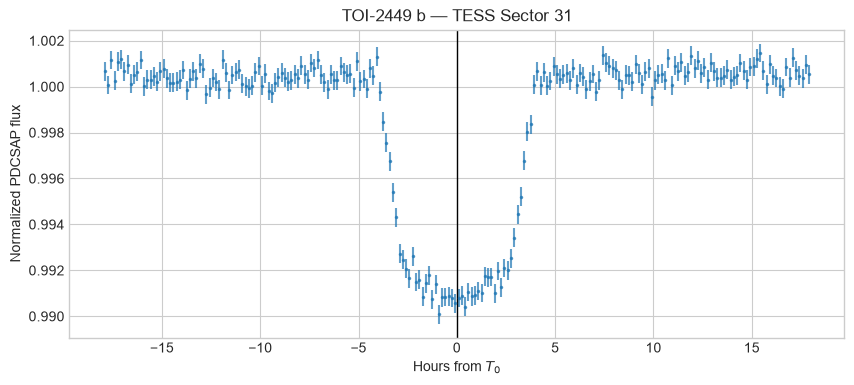

In [8]:
# Inspect the complete transit in Sector 31. Lightkurve uses BTJD = BJD - 2457000.
lc31 = next(lc for lc in collection if int(lc.meta.get("SECTOR", -1)) == 31)
lc31 = lc31.remove_nans().normalize()
t0_btjd = fit_literature.loc[("planet", "t0_bjd"), "value"] - 2457000
time = np.array(lc31.time.value, dtype=float, copy=True)
flux = np.array(lc31.flux.value, dtype=float, copy=True)
flux_err = np.array(lc31.flux_err.value, dtype=float, copy=True)
window = np.abs(time - t0_btjd) < 0.75

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(
    (time[window] - t0_btjd) * 24,
    flux[window],
    yerr=flux_err[window],
    fmt=".", ms=3, alpha=0.7,
)
ax.axvline(0, color="k", lw=1)
ax.set(xlabel="Hours from $T_0$", ylabel="Normalized PDCSAP flux", title="TOI-2449 b — TESS Sector 31")
plt.show()

## 4. Stellar-density diagnostic

Three quantities are compared:

- $\rho_{\star,\mathrm{ind}}=(M_\star/M_\odot)/(R_\star/R_\odot)^3\,\rho_\odot$, obtained independently of the transit;
- $\rho_{\mathrm{circ}}$, the density implied by the published geometry if a circular orbit were enforced;
- the photoeccentric prediction $\rho_{\mathrm{circ}}/\rho_\star=g^3$, where $g=(1+e\sin\omega)/\sqrt{1-e^2}$.

Asymmetric uncertainties are propagated by Monte Carlo. Because the joint posterior chains are not available here, covariances are ignored and the intervals should be regarded as approximate.

In [9]:
rng = np.random.default_rng(2449)
N = 300_000


def split_normal(mu, err_minus, err_plus, size=N):
    """Split normal: use the lower/upper sigma according to the sign of N(0,1)."""
    z = rng.standard_normal(size)
    sigma = np.where(z < 0, err_minus, err_plus)
    return mu + z * sigma


def qsummary(x):
    q16, q50, q84 = np.nanpercentile(x, [16, 50, 84])
    return pd.Series({"median": q50, "err_minus": q50-q16, "err_plus": q84-q50})

# Independent M/R^3 density.
m = split_normal(1.079, 0.048, 0.045)
r = split_normal(1.065, 0.007, 0.007)
rho_sun_si = (M_sun / (4*np.pi*R_sun**3/3)).to_value("kg/m3")
rho_ind = rho_sun_si * m / r**3

# Circular density implied by P, T14, b, and Rp/R*. Exact circular-orbit equation.
P_day = split_normal(106.14468, 0.00021, 0.00022)
T14_hour = split_normal(8.26, 0.06, 0.06)
b = split_normal(0.704, 0.016, 0.015)
p = split_normal(0.0967, 0.0006, 0.0006)
phase = np.pi * (T14_hour / 24) / P_day
a_over_r_circ = np.sqrt(b**2 + ((1+p)**2 - b**2) / np.sin(phase)**2)
rho_circ = 3*np.pi/(G.value*(P_day*86400)**2) * a_over_r_circ**3

# Photoeccentric effect from the fit's native parameters.
x = split_normal(-0.02, 0.06, 0.06)  # sqrt(e) cos(omega)
y = split_normal(-0.31, 0.04, 0.06)  # sqrt(e) sin(omega)
e = x*x + y*y
valid = e < 1
g = np.full(N, np.nan)
g[valid] = (1 + y[valid]*np.sqrt(e[valid])) / np.sqrt(1-e[valid]**2)
g3 = g**3

raw_ratio = rho_circ / rho_ind
corrected_ratio = rho_circ / (g3 * rho_ind)
summary = pd.DataFrame({
    "rho_ind_kg_m3": qsummary(rho_ind),
    "rho_circ_kg_m3": qsummary(rho_circ),
    "g_cubed": qsummary(g3),
    "rho_circ_over_rho_ind": qsummary(raw_ratio),
    "corrected_ratio": qsummary(corrected_ratio),
}).T
summary

,median,err_minus,err_plus
rho_ind_kg_m3,1258.447819,59.758658,59.031123
rho_circ_kg_m3,945.275939,47.280713,49.223781
g_cubed,0.745494,0.057991,0.078404
rho_circ_over_rho_ind,0.751589,0.050055,0.054309
corrected_ratio,1.003382,0.109354,0.118740


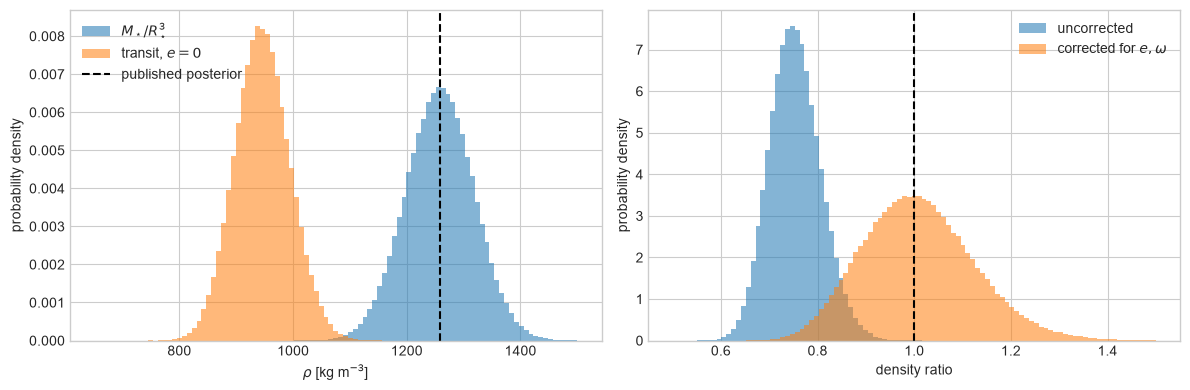

P(corrected ratio < 1) = 0.488
P(|corrected ratio - 1| > 0.20) = 0.078


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(650, 1500, 100)
axes[0].hist(rho_ind, bins=bins, density=True, alpha=.55, label=r"$M_\star/R_\star^3$")
axes[0].hist(rho_circ, bins=bins, density=True, alpha=.55, label=r"transit, $e=0$")
axes[0].axvline(1258, color="k", ls="--", label="published posterior")
axes[0].set(xlabel=r"$\rho$ [kg m$^{-3}$]", ylabel="probability density")
axes[0].legend()

bins = np.linspace(0.5, 1.5, 100)
axes[1].hist(raw_ratio, bins=bins, density=True, alpha=.55, label="uncorrected")
axes[1].hist(corrected_ratio[np.isfinite(corrected_ratio)], bins=bins, density=True, alpha=.55, label=r"corrected for $e,\omega$")
axes[1].axvline(1, color="k", ls="--")
axes[1].set(xlabel=r"density ratio", ylabel="probability density")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"P(corrected ratio < 1) = {np.nanmean(corrected_ratio < 1):.3f}")
print(f"P(|corrected ratio - 1| > 0.20) = {np.nanmean(np.abs(corrected_ratio-1) > .20):.3f}")

## 5. Photoeccentric-effect analysis

In asterodensity profiling, an eccentric orbit changes the density inferred by a circular transit fit according to Kipping (2014):

$$
\Psi(e,\omega)\equiv\frac{\rho_{\star,\mathrm{circ}}}{\rho_{\star,\mathrm{true}}}
=\frac{(1+e\sin\omega)^3}{(1-e^2)^{3/2}}.
$$

We reproduce the two diagnostics used in `PRisma-PhotoEccentric.ipynb`:

1. compare the observed density anomaly, $\Psi_{\mathrm{obs}}=\rho_{\mathrm{circ}}/\rho_{\star,\mathrm{ind}}$, with the distribution predicted from the published $(e,\omega)$ posterior;
2. compare the minimum eccentricity required by $\Psi_{\mathrm{obs}}$ with the measured eccentricity.

For either $\Psi<1$ or $\Psi>1$, the minimum eccentricity is

$$
e_{\min}(\Psi)=\left|\frac{\Psi^{2/3}-1}{\Psi^{2/3}+1}\right|,
$$

reached at apoastron or periastron, respectively.

> **Dependence warning.** The published orbital solution and transit geometry came from the same joint fit, which imposed a stellar-density prior. The calculations below use published one-dimensional summaries and ignore their covariance. They demonstrate consistency with the photoeccentric interpretation but are not an independent detection of it.

In [20]:
def psi_photoeccentric(eccentricity, omega_rad):
    """Circular-fit density ratio Psi from Kipping (2014, Eqs. 33–34)."""
    return (1 + eccentricity*np.sin(omega_rad))**3 / (1-eccentricity**2)**1.5


def emin_from_psi(psi):
    """Smallest eccentricity capable of producing a positive density ratio Psi."""
    psi = np.asarray(psi, dtype=float)
    q = np.power(psi, 2/3)
    return np.abs((q-1)/(q+1))


# Reconstruct the native eccentricity posterior already sampled above.
omega_samples = np.arctan2(y, x)
e_samples = x*x + y*y
physical = (e_samples >= 0) & (e_samples < 1)
psi_predicted = psi_photoeccentric(e_samples[physical], omega_samples[physical])
psi_observed = raw_ratio[np.isfinite(raw_ratio) & (raw_ratio > 0)]
e_min_observed = emin_from_psi(psi_observed)

# Pair independent Monte Carlo draws only for this approximate compatibility statistic.
n_pair = min(len(e_samples[physical]), len(e_min_observed))
compatibility = np.mean(e_samples[physical][:n_pair] >= e_min_observed[:n_pair])
psi_difference = psi_observed[:n_pair] - psi_predicted[:n_pair]

pe_summary = pd.DataFrame({
    "Psi observed": qsummary(psi_observed),
    "Psi predicted from (e, omega)": qsummary(psi_predicted),
    "measured eccentricity": qsummary(e_samples[physical]),
    "minimum required eccentricity": qsummary(e_min_observed),
    "Psi observed - predicted": qsummary(psi_difference),
}).T
pe_summary["unit"] = "dimensionless"
pe_summary.loc["omega", ["median", "err_minus", "err_plus"]] = qsummary(
    np.mod(np.degrees(omega_samples[physical]), 360)
)
pe_summary.loc["omega", "unit"] = "deg"

display(pe_summary)
print(f"P(e >= e_min) ≈ {compatibility:.3f} (summary-statistic approximation)")

,median,err_minus,err_plus,unit
Psi observed,0.751589,0.050055,0.054309,dimensionless
"Psi predicted from (e, omega)",0.745494,0.057991,0.078404,dimensionless
measured eccentricity,0.099439,0.033020,0.027571,dimensionless
minimum required eccentricity,0.094902,0.023093,0.022713,dimensionless
Psi observed - predicted,0.002537,0.087994,0.083069,dimensionless
omega,266.218007,11.243593,11.354263,deg


P(e >= e_min) ≈ 0.534 (summary-statistic approximation)


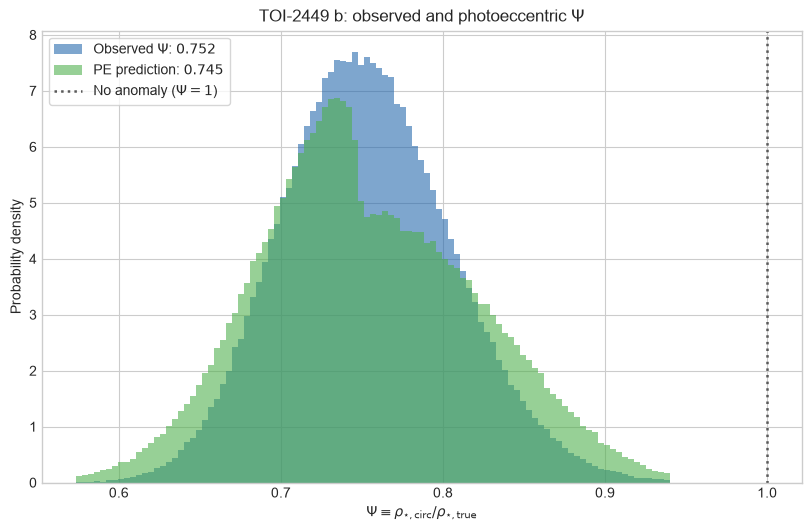

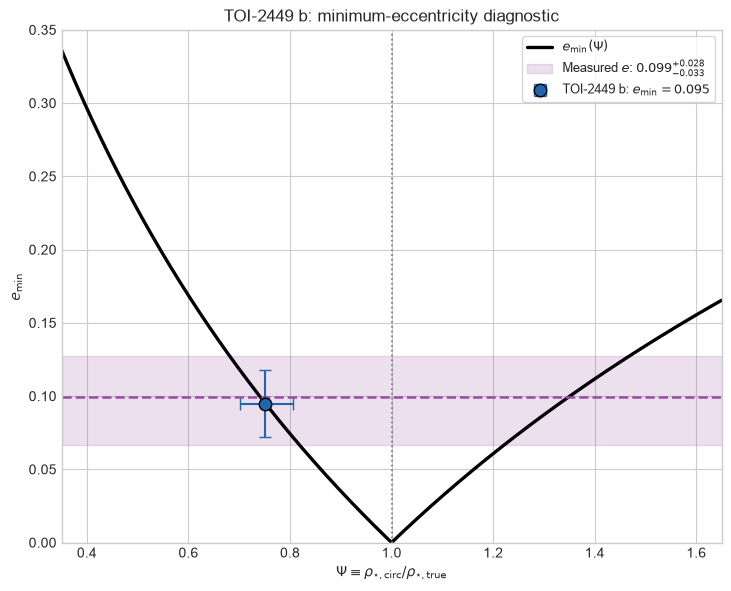

Saved: /Users/jzuluaga/dev/PRisma/papers/TOI2449b/figures/photoeccentric_psi_distribution.png
Saved: /Users/jzuluaga/dev/PRisma/papers/TOI2449b/figures/photoeccentric_emin_diagnostic.png


In [21]:
# Locate the repository and create the figure directory.
pe_repo_root = next(
    (root for root in [Path.cwd(), *Path.cwd().parents]
     if (root / "pipeline" / "exorings").is_dir()),
    None,
)
if pe_repo_root is None:
    raise FileNotFoundError("Could not locate the PRisma repository root.")
pe_figure_dir = pe_repo_root / "papers" / "TOI2449b" / "figures"
pe_figure_dir.mkdir(parents=True, exist_ok=True)

C_OBS = "#2166AC"
C_PE = "#4DAF4A"
C_ECC = "#984EA3"

# Figure 1: observed versus eccentricity-predicted Psi distributions.
fig, ax = plt.subplots(figsize=(8, 5.2), constrained_layout=True)
common_range = (
    min(np.percentile(psi_observed, .2), np.percentile(psi_predicted, .2)),
    max(np.percentile(psi_observed, 99.8), np.percentile(psi_predicted, 99.8)),
)
bins = np.linspace(*common_range, 100)
ax.hist(psi_observed, bins=bins, density=True, alpha=.58, color=C_OBS,
        label=rf"Observed $\Psi$: ${np.median(psi_observed):.3f}$")
ax.hist(psi_predicted, bins=bins, density=True, alpha=.58, color=C_PE,
        label=rf"PE prediction: ${np.median(psi_predicted):.3f}$")
ax.axvline(1, color="0.35", ls=":", lw=1.8, label=r"No anomaly ($\Psi=1$)")
ax.set(
    xlabel=r"$\Psi\equiv\rho_{\star,\rm circ}/\rho_{\star,\rm true}$",
    ylabel="Probability density",
    title=r"TOI-2449 b: observed and photoeccentric $\Psi$",
)
ax.legend(frameon=True)
psi_path = pe_figure_dir / "photoeccentric_psi_distribution.png"
fig.savefig(psi_path, dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: Kipping minimum-eccentricity diagnostic.
psi_grid = np.linspace(0.35, 1.65, 1000)
emin_grid = emin_from_psi(psi_grid)
psi_q = np.percentile(psi_observed, [16, 50, 84])
emin_q = np.percentile(e_min_observed, [16, 50, 84])
e_q = np.percentile(e_samples[physical], [16, 50, 84])

fig, ax = plt.subplots(figsize=(7.2, 5.8), constrained_layout=True)
ax.plot(psi_grid, emin_grid, color="black", lw=2.4, label=r"$e_{\min}(\Psi)$")
ax.axvline(1, color="0.5", ls=":", lw=1.3)
ax.axhspan(e_q[0], e_q[2], color=C_ECC, alpha=.18,
           label=rf"Measured $e$: ${e_q[1]:.3f}^{{+{e_q[2]-e_q[1]:.3f}}}_{{-{e_q[1]-e_q[0]:.3f}}}$")
ax.axhline(e_q[1], color=C_ECC, ls="--", lw=1.8)
ax.errorbar(
    psi_q[1], emin_q[1],
    xerr=[[psi_q[1]-psi_q[0]], [psi_q[2]-psi_q[1]]],
    yerr=[[emin_q[1]-emin_q[0]], [emin_q[2]-emin_q[1]]],
    fmt="o", ms=9, color=C_OBS, ecolor=C_OBS, capsize=4,
    markeredgecolor="black", zorder=5,
    label=rf"TOI-2449 b: $e_{{\min}}={emin_q[1]:.3f}$",
)
ax.set(
    xlabel=r"$\Psi\equiv\rho_{\star,\rm circ}/\rho_{\star,\rm true}$",
    ylabel=r"$e_{\min}$",
    title="TOI-2449 b: minimum-eccentricity diagnostic",
    xlim=(.35, 1.65), ylim=(0, max(.35, e_q[2]*1.8)),
)
ax.legend(fontsize=9, frameon=True)
emin_path = pe_figure_dir / "photoeccentric_emin_diagnostic.png"
fig.savefig(emin_path, dpi=300, bbox_inches="tight")
plt.show()

pe_summary.to_csv(DATA / "photoeccentric_summary.csv")
print("Saved:", psi_path)
print("Saved:", emin_path)

## 6. PhotoRing-effect contour map

This diagram reproduces the approach of `PRisma-ContoursPR.ipynb` for TOI-2449 b. For reference, it adopts a Saturn-like ring ($f_i=1.526$, $f_e=2.269$) with optical depth $\tau=1$ ($\alpha=e^{-1}$), using the measured system geometry ($b=0.704$).

The color field is the dimensionless quantity

$$PR=10\log_{10}\!\left(\rho_{\star,\mathrm{obs}}/\rho_{\star,\mathrm{true}}\right).$$

Two diagnostics are overlaid:

- **orange:** apparent PR when eccentricity is ignored;
- **red:** residual PR after correcting for $(e,\omega)$, which is the relevant quantity when searching for rings.

Dashed lines delimit the 16th–84th percentile interval. The result depends on $(f_i,f_e,\alpha)$ and is not a ring fit.

Importing exorings from: /Users/jzuluaga/dev/PRisma/pipeline


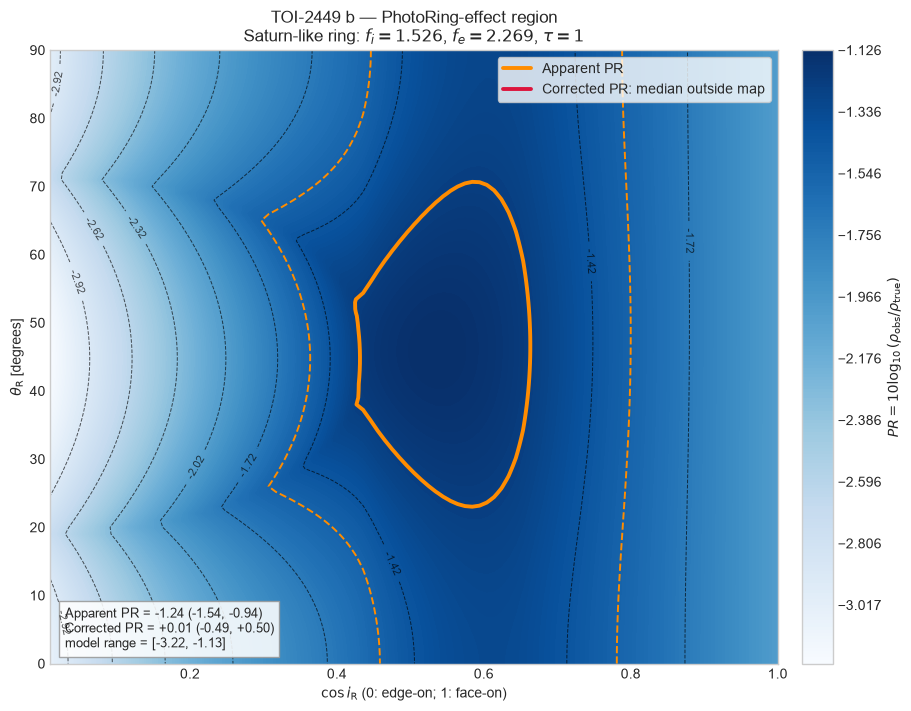

Apparent PR [16, 50, 84]%: [-1.53951812 -1.24019821 -0.93720074]
Corrected PR [16, 50, 84]%: [-0.48648924  0.01466311  0.50039962]
Reference-ring PR range: (np.float64(-3.2161929911148595), np.float64(-1.1255146054824499))


In [22]:
import sys
from matplotlib import colors

# Include pipeline/ even when the kernel starts from papers/TOI2449b.
search_roots = [Path.cwd(), *Path.cwd().parents]
repo_root = next(
    (root for root in search_roots if (root / "pipeline" / "exorings" / "forward.py").is_file()),
    None,
)
if repo_root is None:
    raise FileNotFoundError(
        "Could not find pipeline/exorings/forward.py. Start the notebook inside the PRisma repository."
    )
pipeline_dir = repo_root / "pipeline"
if str(pipeline_dir) not in sys.path:
    sys.path.insert(0, str(pipeline_dir))

from exorings.forward import forward_observables

print("Importing exorings from:", pipeline_dir)

# System parameters and Saturn-like reference ring.
rho_true_gcc = np.nanmedian(rho_ind) / 1000
P_pr = 106.14468
b_pr = 0.704
p_pr = 0.0967
fi_pr, fe_pr, alpha_pr = 1.526, 2.269, np.exp(-1)

cos_i_ring = np.linspace(0.01, 1.0, 101)
theta_ring = np.linspace(0.0, 90.0, 91)
CI, TH = np.meshgrid(cos_i_ring, theta_ring)
PR_map = np.full_like(CI, np.nan, dtype=float)

for j, ci in enumerate(cos_i_ring):
    i_ring_deg = np.degrees(np.arccos(ci))
    for i, theta_deg in enumerate(theta_ring):
        result = forward_observables(
            rho_true_gcc, P_pr, b_pr, p_pr,
            fi_pr, fe_pr, alpha_pr, theta_deg, i_ring_deg,
            bobs_method="kipping",
        )
        if result is not None:
            PR_map[i, j] = 10 * result["logPR"]

# Apparent and corrected PR propagated from the previous section's samples.
pr_raw = 10 * np.log10(raw_ratio[np.isfinite(raw_ratio) & (raw_ratio > 0)])
pr_corrected = 10 * np.log10(corrected_ratio[np.isfinite(corrected_ratio) & (corrected_ratio > 0)])
raw_q = np.percentile(pr_raw, [16, 50, 84])
corrected_q = np.percentile(pr_corrected, [16, 50, 84])

zmin, zmax = np.nanmin(PR_map), np.nanmax(PR_map)
levels = np.linspace(zmin, zmax, 200)
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
cf = ax.contourf(CI, TH, PR_map, levels=levels, cmap="Blues", norm=colors.Normalize(zmin, zmax))
base = ax.contour(CI, TH, PR_map, levels=np.linspace(zmin, zmax, 8), colors="k", linewidths=.7, alpha=.65)
ax.clabel(base, fmt="%.2f", fontsize=8)

# Median and 16th–84th percentile limits; draw only levels that cross the map.
def draw_pr_interval(q, color, label):
    median_is_visible = zmin <= q[1] <= zmax
    for level, style, width in zip(q, ["--", "-", "--"], [1.4, 2.8, 1.4]):
        if zmin <= level <= zmax:
            ax.contour(CI, TH, PR_map, levels=[level], colors=color, linestyles=style, linewidths=width)
    legend_label = label if median_is_visible else f"{label}: median outside map"
    ax.plot([], [], color=color, lw=2.8, label=legend_label)

draw_pr_interval(raw_q, "darkorange", "Apparent PR")
draw_pr_interval(corrected_q, "crimson", "Corrected PR")

cbar = fig.colorbar(cf, ax=ax, pad=.02)
cbar.set_label(r"$PR=10\log_{10}(\rho_{\rm obs}/\rho_{\rm true})$")
ax.set(
    xlabel=r"$\cos i_{\rm R}$ (0: edge-on; 1: face-on)",
    ylabel=r"$\theta_{\rm R}$ [degrees]",
    title="TOI-2449 b — PhotoRing-effect region\n"
          rf"Saturn-like ring: $f_i={fi_pr:.3f}$, $f_e={fe_pr:.3f}$, $\tau=1$",
)
ax.legend(loc="best", frameon=True)
ax.text(
    .02, .02,
    f"Apparent PR = {raw_q[1]:+.2f} ({raw_q[0]:+.2f}, {raw_q[2]:+.2f})\n"
    f"Corrected PR = {corrected_q[1]:+.2f} ({corrected_q[0]:+.2f}, {corrected_q[2]:+.2f})\n"
    f"model range = [{zmin:+.2f}, {zmax:+.2f}]",
    transform=ax.transAxes, va="bottom", ha="left", fontsize=9,
    bbox=dict(facecolor="white", alpha=.88, edgecolor="0.6"),
)
plt.show()

print("Apparent PR [16, 50, 84]%:", raw_q)
print("Corrected PR [16, 50, 84]%:", corrected_q)
print("Reference-ring PR range:", (zmin, zmax))

In [23]:
raw_q[1]-raw_q[0], raw_q[1]-raw_q[2]

(np.float64(0.2993199101540678), np.float64(-0.30299746889209744))

### Uncorrected-PR contour in the PRisma style

The next figure isolates the **apparent, uncorrected PR** and follows the visual design of `papers/kepler51/figures/PRContour-Saturn.png`. Ringed-planet glyphs show the simulated orientation at representative points in $(\cos i_R,\theta_R)$ space. The thick orange contour marks the median apparent PR, while the dashed orange contours mark its 16th–84th percentile interval.

This is intentionally the uncorrected diagnostic: it shows where TOI-2449 b would appear in PhotoRing space if orbital eccentricity were ignored.

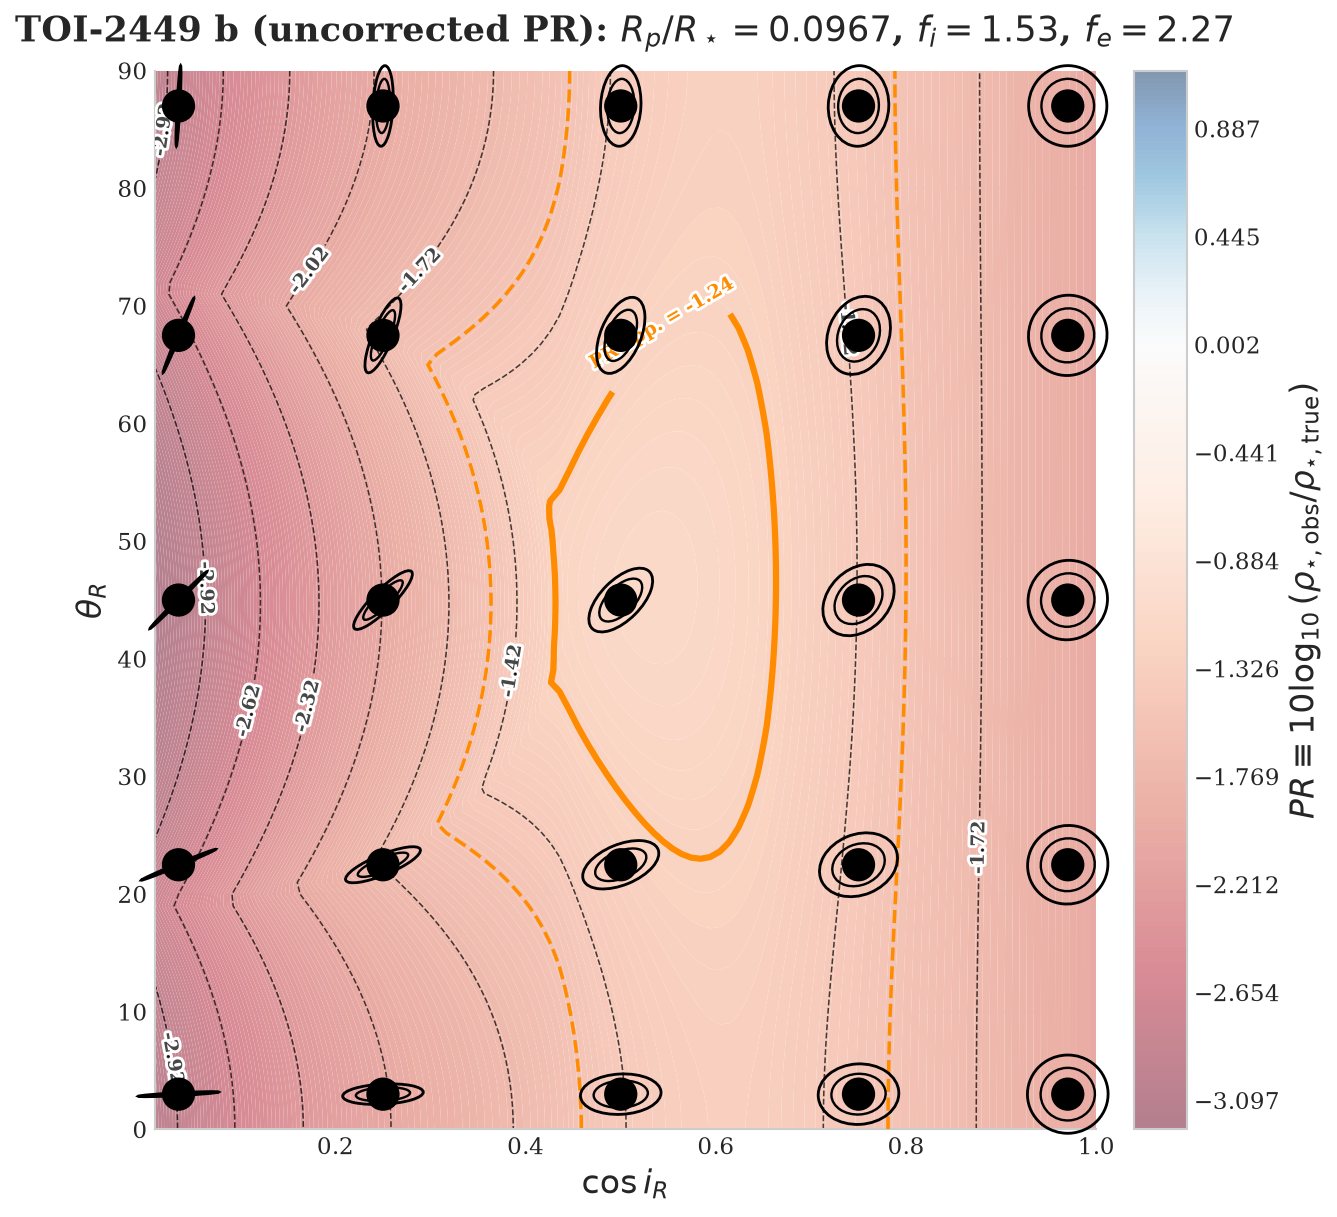

Saved: /Users/jzuluaga/dev/PRisma/papers/TOI2449b/figures/PRContour-TOI2449b-uncorrected.png


In [24]:
from matplotlib import patheffects as pe
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.offsetbox import AnnotationBbox, DrawingArea
from matplotlib.patches import Circle, Ellipse

# Match the serif, muted diverging style of PRContour-Saturn.png.
with plt.rc_context({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "axes.labelsize": 16,
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.28,
    "grid.color": "gray",
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
}):
    fig, ax = plt.subplots(figsize=(8.4, 8.0), constrained_layout=True)

    # Softened RdBu palette, as used by the PRisma Saturn contour figure.
    base_colors = plt.colormaps["RdBu"](np.linspace(0, 1, 256))
    soft_colors = 0.50 * base_colors + 0.50 * np.ones_like(base_colors)
    prisma_cmap = LinearSegmentedColormap.from_list("prisma_soft_RdBu", soft_colors)

    # Include zero in the color scale even though this Saturn-like model is negative everywhere.
    pr_vmin = float(np.nanmin(PR_map))
    pr_vmax = max(0.5, 0.35 * abs(pr_vmin))
    pr_norm = TwoSlopeNorm(vmin=pr_vmin, vcenter=0.0, vmax=pr_vmax)
    filled_levels = np.linspace(pr_vmin, pr_vmax, 256)
    cf = ax.contourf(
        CI, TH, PR_map,
        levels=filled_levels, cmap=prisma_cmap, norm=pr_norm,
        antialiased=True, extend="neither",
    )

    # Labeled model contours.
    model_levels = np.linspace(np.nanmin(PR_map), np.nanmax(PR_map), 8)
    cs = ax.contour(CI, TH, PR_map, levels=model_levels, colors="black", linewidths=.75, alpha=.72)
    contour_labels = ax.clabel(cs, fmt="%.2f", fontsize=9, inline=True, inline_spacing=3)
    for label in contour_labels:
        label.set_fontweight("bold")
        label.set_path_effects([pe.withStroke(linewidth=2.8, foreground="white")])

    # Uncorrected observed PR: median (thick) and 16th–84th percentiles (dashed).
    for level, style, width in zip(raw_q, ["--", "-", "--"], [1.7, 3.0, 1.7]):
        if np.nanmin(PR_map) <= level <= np.nanmax(PR_map):
            observed_cs = ax.contour(
                CI, TH, PR_map, levels=[level], colors="darkorange",
                linestyles=style, linewidths=width, zorder=8,
            )
            if style == "-":
                observed_labels = ax.clabel(
                    observed_cs, fmt={level: f"PR app. = {level:+.2f}"},
                    fontsize=9, inline=True,
                )
                for label in observed_labels:
                    label.set_fontweight("bold")
                    label.set_path_effects([pe.withStroke(linewidth=2.8, foreground="white")])

    def add_ring_glyph(ax, x, y, cos_i, theta_deg, size=44):
        """Draw a fixed-size projected ring system at a contour-grid position."""
        canvas = DrawingArea(size, size, clip=False)
        center = size / 2
        outer = 0.88 * size
        inner = outer * fi_pr / fe_pr
        flattening = max(float(cos_i), 0.025)
        for diameter, lw in [(outer, 1.35), (inner, 1.15)]:
            canvas.add_artist(Ellipse(
                (center, center), diameter, diameter * flattening,
                angle=theta_deg, fill=False, edgecolor="black", linewidth=lw,
            ))
        canvas.add_artist(Circle((center, center), 0.17 * size, color="black", zorder=5))
        ax.add_artist(AnnotationBbox(canvas, (x, y), frameon=False, pad=0, zorder=10))

    # Same representative orientation grid used by the Saturn-style diagram.
    for xg in [0.035, 0.25, 0.50, 0.75, 0.97]:
        for yg in [3.0, 22.5, 45.0, 67.5, 87.0]:
            add_ring_glyph(ax, xg, yg, xg, yg)

    ax.set_xlim(0.01, 1.0)
    ax.set_ylim(0, 90)
    ax.set_xlabel(r"$\cos i_R$")
    ax.set_ylabel(r"$\theta_R$")
    ax.set_title(
        rf"TOI-2449 b (uncorrected PR): $R_p/R_\star={p_pr:.4f}$, $f_i={fi_pr:.2f}$, $f_e={fe_pr:.2f}$",
        pad=14,
    )

    cbar = fig.colorbar(cf, ax=ax, pad=.02)
    cbar.set_label(r"$PR\equiv10\log_{10}(\rho_{\star,\rm obs}/\rho_{\star,\rm true})$")

    figure_dir = repo_root / "papers" / "TOI2449b" / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    uncorrected_pr_path = figure_dir / "PRContour-TOI2449b-uncorrected.png"
    fig.savefig(uncorrected_pr_path, bbox_inches="tight")
    plt.show()

print("Saved:", uncorrected_pr_path)

In [14]:
summary.to_csv(DATA / "density_diagnostic_summary.csv")

rho0 = rho_sun_si * 1.079 / 1.065**3
p0, t0, b0, P0 = 0.0967, 8.26/24, 0.704, 106.14468
ar0 = np.sqrt(b0**2 + ((1+p0)**2-b0**2)/np.sin(np.pi*t0/P0)**2)
rho_circ0 = 3*np.pi/(G.value*(P0*86400)**2)*ar0**3
e0, omega0 = 0.098, np.deg2rad(266)
g30 = ((1+e0*np.sin(omega0))/np.sqrt(1-e0**2))**3

print(f"Central values: rho_ind={rho0:.1f}, rho_circ={rho_circ0:.1f} kg/m3")
print(f"rho_circ/rho_ind={rho_circ0/rho0:.3f}; g^3={g30:.3f}")
print(f"corrected ratio={(rho_circ0/rho0)/g30:.3f}")

Central values: rho_ind=1259.3, rho_circ=944.7 kg/m3
rho_circ/rho_ind=0.750; g^3=0.745
corrected ratio=1.007


/Users/jzuluaga/dev/PRisma/pipeline/exorings/forward.py:159: RuntimeWarning: invalid value encountered in scalar power
  bobs = (((1 - pobs)**2 - (sfF / sfT) * (1 + pobs)**2) / (1 - sfF / sfT))**0.5


,median,err_minus,err_plus
true planet radius [Rj],0.652324,0.030129,0.208952
outer ring radius [Rj],1.480123,0.068362,0.474112
planet density with rings [g/cm3],3.070542,1.673738,0.565879
literature ringless density [g/cm3],0.862881,0.053660,0.054227
true impact parameter,0.614104,0.001045,0.001016


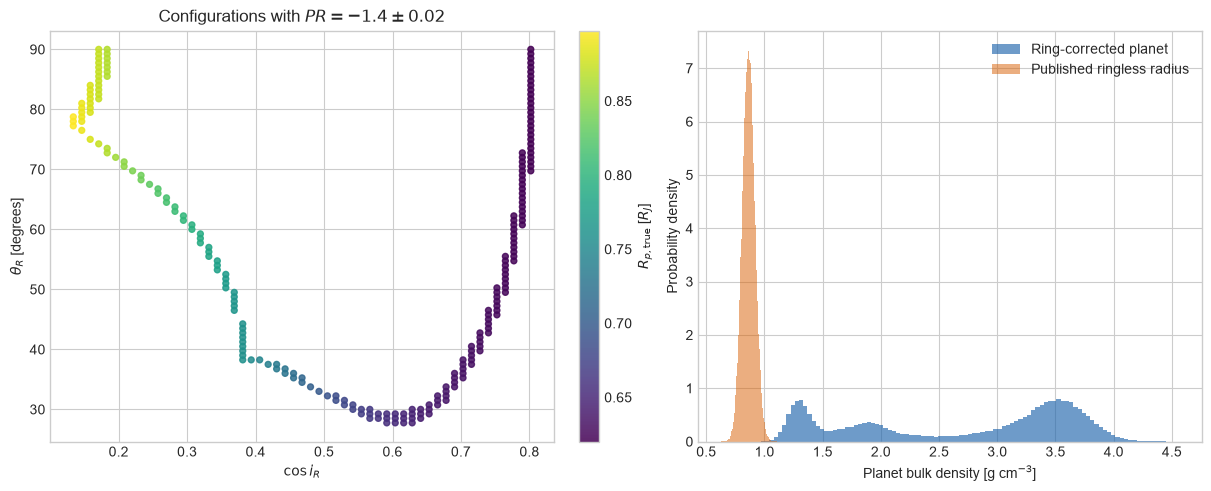

Accepted orientation cells: 233
Saved: /Users/jzuluaga/dev/PRisma/papers/TOI2449b/figures/ring_corrected_planet_density_PRminus1p4.png
Counterfactual ring interpretation: Rp = 0.652 +0.209/-0.030 Rj; rho_p = 3.07 +0.57/-1.67 g/cm3.
PR=-1.4 does not imply one unique radius: the orientation degeneracy makes the posterior strongly non-Gaussian and multimodal, so inspect the histogram.
Important: this counterfactual assigns the full uncorrected PR to rings. After the published eccentricity correction, the residual PR is near zero, so this large radius/density correction is not supported by the current data.


In [26]:
# Ring-corrected planet radius and density conditional on PR = -1.4
# -----------------------------------------------------------------
# This is not a ring detection. It asks: under the adopted Saturn-like ring model,
# which true planet radii reproduce the published ringless-fit p_obs and b_obs while
# also lying on the requested PR contour? Ring mass is neglected, so the RV mass is
# assigned entirely to the planet.
import sys
from scipy.optimize import brentq
from astropy.constants import M_jup, R_jup

PR_TARGET = -1.4
PR_TOLERANCE = 0.02       # finite numerical slice around the target contour
P_OBS = 0.0967            # published ringless-fit Rp/Rstar
B_OBS = 0.704             # published ringless-fit impact parameter
FI_RING, FE_RING = 1.526, 2.269
ALPHA_RING = np.exp(-1)   # tau = 1
RHO_STAR_GCC = np.median(rho_ind) / 1000
PERIOD_DAYS = 106.14468

# Ensure pipeline/exorings is importable when this cell is run independently.
ring_repo_root = next(
    (root for root in [Path.cwd(), *Path.cwd().parents]
     if (root / "pipeline" / "exorings" / "forward.py").is_file()),
    None,
)
if ring_repo_root is None:
    raise FileNotFoundError("Could not locate pipeline/exorings/forward.py")
if str(ring_repo_root / "pipeline") not in sys.path:
    sys.path.insert(0, str(ring_repo_root / "pipeline"))
from exorings.forward import forward_observables


def solve_ring_configuration(cos_i_ring, theta_ring_deg):
    """Return (p_true, b_true, PR) constrained to the observed p_obs and b_obs."""
    i_ring_deg = np.degrees(np.arccos(cos_i_ring))

    # p_obs/p_true is an area factor fixed by ring geometry; estimate it once.
    reference = forward_observables(
        RHO_STAR_GCC, PERIOD_DAYS, 0.0, 0.05,
        FI_RING, FE_RING, ALPHA_RING, theta_ring_deg, i_ring_deg,
    )
    if reference is None or not np.isfinite(reference["pobs"]):
        return None
    p_true = P_OBS / (reference["pobs"] / 0.05)

    def impact_residual(b_true):
        result = forward_observables(
            RHO_STAR_GCC, PERIOD_DAYS, b_true, p_true,
            FI_RING, FE_RING, ALPHA_RING, theta_ring_deg, i_ring_deg,
        )
        if result is None or not np.isfinite(result["bobs"]):
            return np.nan
        return result["bobs"] - B_OBS

    # Search only the physically transiting interval and bracket every possible root.
    A = FE_RING * p_true
    B = A * cos_i_ring
    theta = np.radians(theta_ring_deg)
    projected_half_height = max(p_true, A*abs(np.sin(theta)), B*abs(np.cos(theta)))
    b_upper = max(1e-4, min(0.98, 1-projected_half_height-1e-6))
    b_grid = np.linspace(0, b_upper, 28)
    residuals = np.array([impact_residual(b) for b in b_grid])

    roots = []
    for k in range(len(b_grid)-1):
        pair = residuals[k:k+2]
        if np.all(np.isfinite(pair)) and pair[0]*pair[1] <= 0:
            try:
                roots.append(brentq(impact_residual, b_grid[k], b_grid[k+1]))
            except ValueError:
                pass
    if not roots:
        return None

    # The smallest-b branch is continuous with the usual transit solution.
    b_true = min(roots)
    result = forward_observables(
        RHO_STAR_GCC, PERIOD_DAYS, b_true, p_true,
        FI_RING, FE_RING, ALPHA_RING, theta_ring_deg, i_ring_deg,
    )
    if result is None:
        return None
    return p_true, b_true, 10*result["logPR"]


# Uniform grids in cos(i_R) and theta_R correspond to an isotropic orientation prior.
ring_rows = []
for cos_i_ring in np.linspace(0.01, 1.0, 81):
    for theta_ring_deg in np.linspace(0, 90, 121):
        solution = solve_ring_configuration(cos_i_ring, theta_ring_deg)
        if solution is not None:
            p_true, b_true, pr_value = solution
            if abs(pr_value-PR_TARGET) <= PR_TOLERANCE:
                ring_rows.append((cos_i_ring, theta_ring_deg, p_true, b_true, pr_value))

ring_slice = pd.DataFrame(
    ring_rows, columns=["cos_i_ring", "theta_ring_deg", "p_true", "b_true", "PR"]
)
if ring_slice.empty:
    raise RuntimeError("No ring configurations reached the requested PR contour.")

# Propagate orientation degeneracy plus the published Mplanet and Rstar uncertainties.
rng_density = np.random.default_rng(2449)
N_DENSITY = 200_000
orientation_index = rng_density.integers(0, len(ring_slice), N_DENSITY)
p_true_mc = ring_slice["p_true"].to_numpy()[orientation_index]

def local_split_normal(mu, err_minus, err_plus, size):
    z = rng_density.standard_normal(size)
    return mu + z*np.where(z < 0, err_minus, err_plus)

m_planet_mj = local_split_normal(0.70, 0.04, 0.04, N_DENSITY)
r_star_rsun = local_split_normal(1.065, 0.007, 0.007, N_DENSITY)
r_planet_rj = p_true_mc * r_star_rsun * R_sun.value / R_jup.value
r_ring_outer_rj = FE_RING * r_planet_rj
rho_planet_gcc = (
    m_planet_mj*M_jup.value /
    ((4*np.pi/3)*(r_planet_rj*R_jup.value)**3)
) / 1000

# Literature value under the ringless interpretation, for comparison.
r_literature_rj = local_split_normal(1.002, 0.009, 0.009, N_DENSITY)
rho_literature_gcc = (
    m_planet_mj*M_jup.value /
    ((4*np.pi/3)*(r_literature_rj*R_jup.value)**3)
) / 1000

ring_density_summary = pd.DataFrame({
    "true planet radius [Rj]": qsummary(r_planet_rj),
    "outer ring radius [Rj]": qsummary(r_ring_outer_rj),
    "planet density with rings [g/cm3]": qsummary(rho_planet_gcc),
    "literature ringless density [g/cm3]": qsummary(rho_literature_gcc),
    "true impact parameter": qsummary(ring_slice["b_true"].to_numpy()),
}).T
display(ring_density_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
scatter = axes[0].scatter(
    ring_slice["cos_i_ring"], ring_slice["theta_ring_deg"],
    c=ring_slice["p_true"]*1.065*R_sun.value/R_jup.value,
    s=18, cmap="viridis", alpha=.85,
)
fig.colorbar(scatter, ax=axes[0], label=r"$R_{p,\rm true}$ [$R_J$]")
axes[0].set(
    xlabel=r"$\cos i_R$", ylabel=r"$\theta_R$ [degrees]",
    title=rf"Configurations with $PR={PR_TARGET}\pm{PR_TOLERANCE}$",
)

axes[1].hist(rho_planet_gcc, bins=100, density=True, alpha=.65,
             color="#2166AC", label="Ring-corrected planet")
axes[1].hist(rho_literature_gcc, bins=100, density=True, alpha=.50,
             color="#D95F02", label="Published ringless radius")
axes[1].set(xlabel=r"Planet bulk density [g cm$^{-3}$]", ylabel="Probability density")
axes[1].legend()

ring_density_figure = (
    ring_repo_root / "papers" / "TOI2449b" / "figures" /
    "ring_corrected_planet_density_PRminus1p4.png"
)
fig.savefig(ring_density_figure, dpi=300, bbox_inches="tight")
plt.show()

ring_slice.to_csv(DATA / "ring_configurations_PRminus1p4.csv", index=False)
ring_density_summary.to_csv(DATA / "ring_corrected_density_summary.csv")
radius_q = qsummary(r_planet_rj)
density_q = qsummary(rho_planet_gcc)
print(f"Accepted orientation cells: {len(ring_slice)}")
print("Saved:", ring_density_figure)
print(
    f"Counterfactual ring interpretation: Rp = {radius_q['median']:.3f} "
    f"+{radius_q['err_plus']:.3f}/-{radius_q['err_minus']:.3f} Rj; "
    f"rho_p = {density_q['median']:.2f} "
    f"+{density_q['err_plus']:.2f}/-{density_q['err_minus']:.2f} g/cm3."
)
print(
    "PR=-1.4 does not imply one unique radius: the orientation degeneracy makes "
    "the posterior strongly non-Gaussian and multimodal, so inspect the histogram."
)
print(
    "Important: this counterfactual assigns the full uncorrected PR to rings. "
    "After the published eccentricity correction, the residual PR is near zero, "
    "so this large radius/density correction is not supported by the current data."
)

## 8. Eccentricity threshold for a ring interpretation

We define a conservative operational criterion for when the photoeccentric effect is unable to explain the observed density anomaly. For each Monte Carlo draw of $\Psi_{\rm obs}$, the smallest dynamically capable eccentricity is

$$
e_{\min}(\Psi)=\left|\frac{\Psi^{2/3}-1}{\Psi^{2/3}+1}\right|.
$$

For a fixed trial eccentricity $e_0$, the probability that the photoeccentric effect is geometrically capable of producing the anomaly—allowing the most favorable $\omega$—is

$$
p_{\rm PE}(e_0)=P\!\left[e_{\min}(\Psi_{\rm obs})\le e_0\right].
$$

The limiting eccentricity for $p_{\rm PE}<0.05$ is therefore the fifth percentile of the $e_{\min}$ distribution. This is an operational posterior probability, not a frequentist p-value. It is deliberately conservative because it optimizes over $\omega$.

In [27]:
# Maximum eccentricity for which PE feasibility remains below 5%.
PE_PROBABILITY_LIMIT = 0.05
e_threshold_5pct = np.quantile(e_min_observed, PE_PROBABILITY_LIMIT)
e_required_central = np.median(e_min_observed)

# Checks against the reconstructed eccentricity posterior from the joint fit.
e_published = e_samples[physical]
published_below_threshold = np.mean(e_published < e_threshold_5pct)
pe_feasibility_at_published_median = np.mean(e_min_observed <= np.median(e_published))

# At the threshold and the most favorable apoastron geometry (omega = 270 deg),
# this is the smallest density ratio that PE can generate.
psi_min_at_threshold = ((1-e_threshold_5pct)/(1+e_threshold_5pct))**1.5

threshold_report = pd.DataFrame({
    "quantity": [
        "maximum e for p_PE < 0.05",
        "e required by central Psi",
        "Psi reachable at e threshold and omega=270 deg",
        "joint-fit posterior probability e < threshold",
        "PE feasibility at joint-fit median e",
    ],
    "value": [
        e_threshold_5pct,
        e_required_central,
        psi_min_at_threshold,
        published_below_threshold,
        pe_feasibility_at_published_median,
    ],
    "interpretation": [
        "Below this eccentricity, PE is incapable of explaining the anomaly in >95% of density draws",
        "Minimum eccentricity needed to reproduce the median density anomaly at optimal omega",
        "Corresponds to the upper 95% boundary of the observed density deficit",
        "Fraction of the published joint-fit eccentricity posterior in the ring-favorable regime",
        "Fraction of density draws geometrically explainable by PE at the published median eccentricity",
    ],
})
display(threshold_report)
threshold_report.to_csv(DATA / "photoeccentric_eccentricity_threshold.csv", index=False)

print(f"Conservative threshold: e < {e_threshold_5pct:.4f} gives p_PE < 0.05")
print(f"Central anomaly requires e_min = {e_required_central:.3f}")
print(f"Published joint-fit posterior below threshold: {published_below_threshold:.1%}")
print(
    "Conclusion: a ring interpretation becomes necessary at the 95% level only "
    f"if an independent RV-only analysis constrains e below approximately {e_threshold_5pct:.4f}."
)
print(
    "Caveat: the published eccentricity posterior is not independent because the "
    "photometry and stellar-density prior were included in the same joint fit."
)

,quantity,value,interpretation
0,maximum e for p_PE < 0.05,0.056483,"Below this eccentricity, PE is incapable of ex..."
1,e required by central Psi,0.094902,Minimum eccentricity needed to reproduce the m...
2,Psi reachable at e threshold and omega=270 deg,0.843977,Corresponds to the upper 95% boundary of the o...
3,joint-fit posterior probability e < threshold,0.091683,Fraction of the published joint-fit eccentrici...
4,PE feasibility at joint-fit median e,0.577430,Fraction of density draws geometrically explai...


Conservative threshold: e < 0.0565 gives p_PE < 0.05
Central anomaly requires e_min = 0.095
Published joint-fit posterior below threshold: 9.2%
Conclusion: a ring interpretation becomes necessary at the 95% level only if an independent RV-only analysis constrains e below approximately 0.0565.
Caveat: the published eccentricity posterior is not independent because the photometry and stellar-density prior were included in the same joint fit.


## 7. Interpretation and next test

Using the central values:

- the independent stellar density is approximately **1258 kg m⁻³**;
- treating the geometry as circular gives approximately **945 kg m⁻³**, an apparent deficit of about 25%;
- the observed anomaly is $\Psi_{\rm obs}=0.752^{+0.054}_{-0.050}$;
- the published eccentric solution predicts $\Psi_{\rm PE}=0.745^{+0.078}_{-0.058}$;
- the anomaly requires $e_{\min}=0.095\pm0.023$, consistent with the measured $e=0.099^{+0.028}_{-0.033}$ and $\omega=266.2\pm11.3^\circ$;
- after the photoeccentric correction, the central density ratio returns to approximately **1.01**.

The two photoeccentric diagnostics therefore show that the measured orbit naturally explains the circular-density deficit. Under the summary-statistic approximation, $P(e\ge e_{\min})\simeq0.53$ and $\Psi_{\rm obs}-\Psi_{\rm PE}=0.003^{+0.083}_{-0.088}$, fully consistent with zero. This is a consistency test—not an independent detection—because the transit geometry, eccentricity, and stellar-density prior entered the same published joint fit.

The PhotoRing map clarifies the degeneracy: the apparent PR ($\sim-1.24$) crosses the region produced by a Saturn-like ring, but the corrected PR ($\sim+0.01$) lies outside this model's range ($-3.22$ to $-1.13$). Therefore, **the published summary statistics show neither a residual density anomaly nor support for this reference ring**: the circular-density discrepancy is the expected photoeccentric signal. The published $\rho_\star$ posterior cannot serve as an independent validation because it reproduces the stellar prior.

### Recommended decisive analysis

1. Fit only the TESS Sector 31 transit, using external information for $P$ and $T_0$ while leaving $a/R_\star$ (or $\rho_\mathrm{circ}$), $b$, $R_p/R_\star$, and limb darkening free.
2. **Do not impose a prior on $\rho_\star$** in this fit.
3. Retain the joint posterior samples rather than propagating medians as if they were independent.
4. Then combine them with the independent $M_\star,R_\star$ posterior and the RV posterior for $(e,\omega)$.
5. Evaluate $A=\rho_\mathrm{circ}/(g^3\rho_{\star,\mathrm{ind}})$; only a robust deviation from $A=1$ would justify investigating blends, spots, dilution, limb-darkening errors, precession, or ring structures.

The main limitation is that TESS observed **only one transit**, although it was complete and had a published residual scatter of 408 ppm. The period depends on NGTS/RV, and the density inference will be strongly covariant with $b$, limb darkening, and the local baseline. A scientific claim requires the original `juliet` chains or the independent refit described above.